In [1]:
# !pip install torchmetrics optuna

In [2]:
import torch
import torchvision
import torchmetrics

In [3]:
import torchvision.transforms.v2 as T
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from sklearn.datasets import load_sample_images

In [6]:
response = load_sample_images()

In [7]:
response.keys()

dict_keys(['images', 'filenames', 'DESCR'])

In [82]:
sample_images = response['images']
sample_images[1].shape

(427, 640, 3)

In [83]:
sample_images[1][:, : , 0].shape

(427, 640)

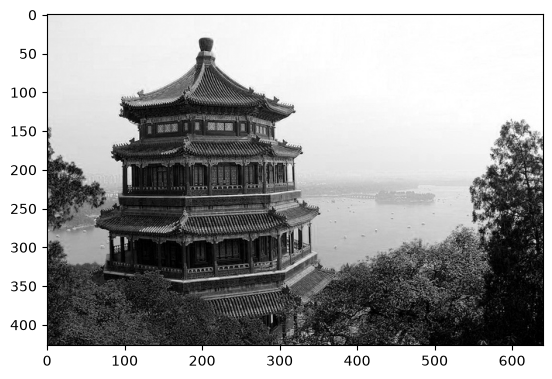

In [86]:
plt.imshow(sample_images[0][:, : , 2], cmap='gray')

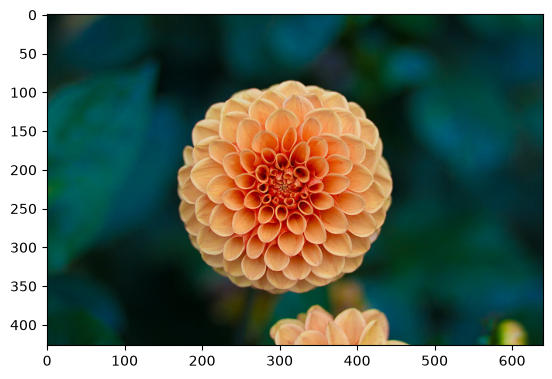

In [35]:
plt.imshow(sample_images[1])

In [41]:
sample_images = np.stack(sample_images)
sample_images.shape

(2, 427, 640, 3)

In [46]:
sample_images = torch.FloatTensor(sample_images)
sample_images.shape

torch.Size([2, 427, 640, 3])

In [50]:
sample_images = sample_images/255
sample_images

tensor([[[[0.6824, 0.7882, 0.9059],
          [0.6824, 0.7882, 0.9059],
          [0.6824, 0.7882, 0.9059],
          ...,
          [0.9804, 0.9843, 1.0000],
          [0.9804, 0.9843, 1.0000],
          [0.9804, 0.9843, 1.0000]],

         [[0.6745, 0.7804, 0.8980],
          [0.6784, 0.7843, 0.9020],
          [0.6784, 0.7843, 0.9020],
          ...,
          [0.9843, 0.9882, 1.0000],
          [0.9843, 0.9882, 1.0000],
          [0.9843, 0.9882, 1.0000]],

         [[0.6824, 0.7882, 0.9059],
          [0.6824, 0.7882, 0.9059],
          [0.6824, 0.7882, 0.9059],
          ...,
          [0.9882, 0.9922, 1.0000],
          [0.9882, 0.9922, 1.0000],
          [0.9882, 0.9922, 1.0000]],

         ...,

         [[0.3451, 0.3137, 0.0275],
          [0.5765, 0.5412, 0.2706],
          [0.4784, 0.4549, 0.1490],
          ...,
          [0.1529, 0.1647, 0.1294],
          [0.0314, 0.0549, 0.0078],
          [0.0235, 0.0471, 0.0000]],

         [[0.4784, 0.4392, 0.1608],
          [0.5059

In [52]:
sample_images.shape

torch.Size([2, 427, 640, 3])

In [54]:
sample_images_permuted = sample_images.permute(0, 3, 1, 2)
sample_images_permuted.shape

torch.Size([2, 3, 427, 640])

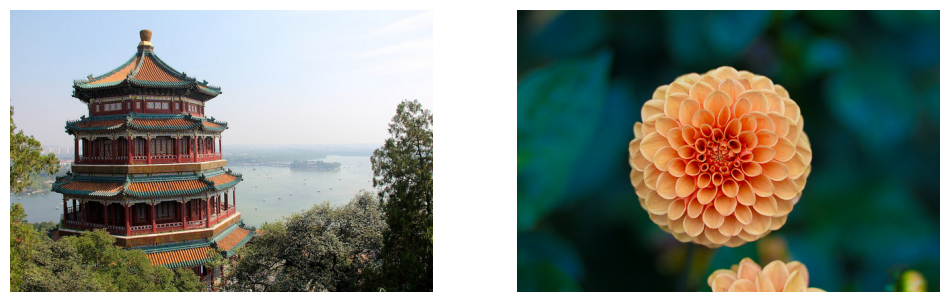

In [68]:
def plot_image(img_tensor):
    plt.imshow(img_tensor.permute(1,2,0))
    plt.axis('off')

plt.figure(figsize=(12,6))
for ind, img_tensor in enumerate(sample_images_permuted):
    plt.subplot(1,2,ind+1)
    plot_image(img_tensor)


In [75]:
import torchvision.transforms.v2 as T

cropper = T.CenterCrop((70,120))
cropped_images = cropper(sample_images_permuted)
cropped_images.shape

torch.Size([2, 3, 70, 120])

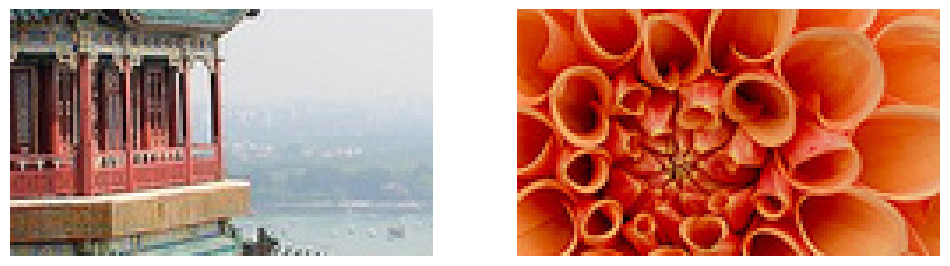

In [76]:
plt.figure(figsize=(12,6))
for ind, img_tensor in enumerate(cropped_images):
    plt.subplot(1,2,ind+1)
    plot_image(img_tensor)


In [81]:
cropped_images[0].flatten().shape

torch.Size([25200])

# convolutional layer (CNN - convolutional neural network)

In [89]:
conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7)
output = conv_layer(cropped_images)
output.shape

torch.Size([2, 32, 64, 114])

In [90]:
conv_layer2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5)
output2 = conv_layer2(output)
output2.shape

torch.Size([2, 64, 60, 110])

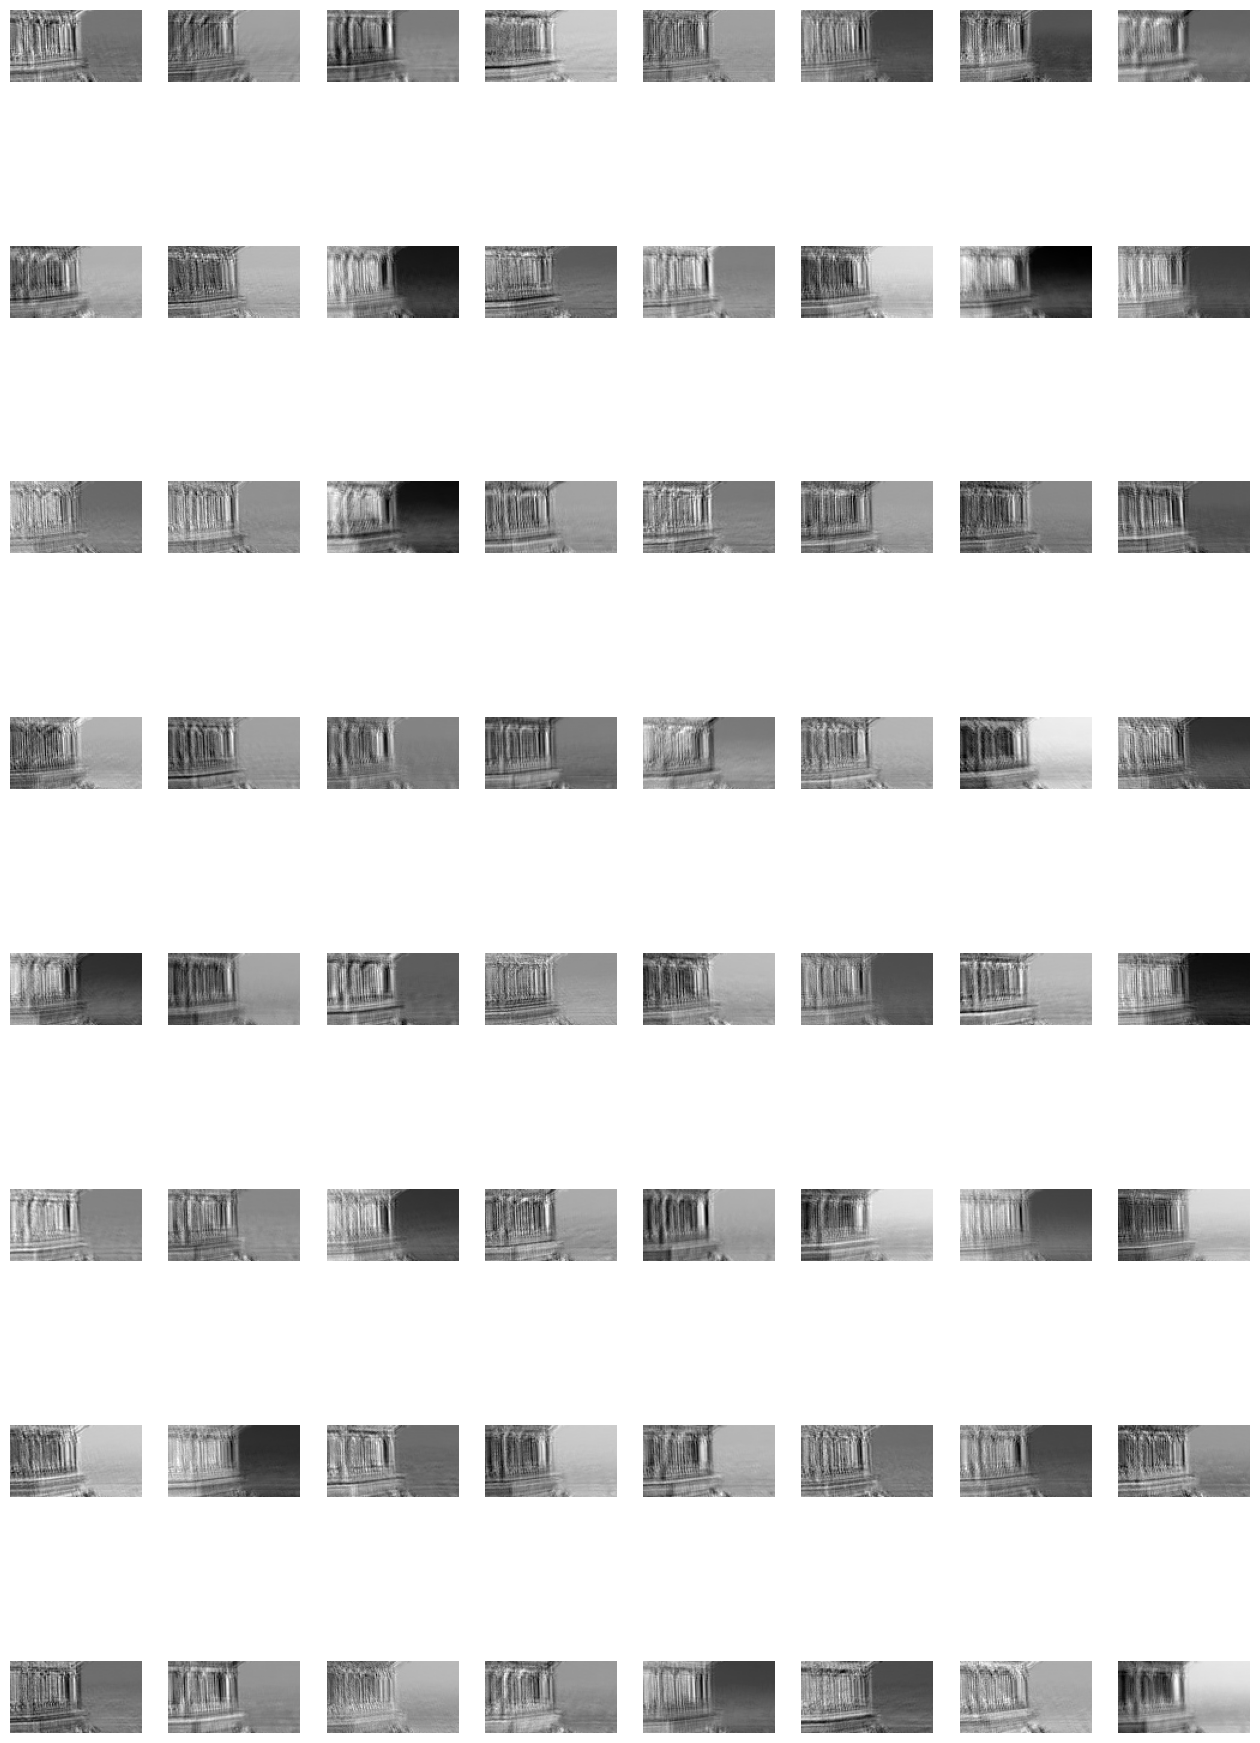

In [93]:
fig,axs = plt.subplots(8,8,figsize=(16,24))

for ind, ax in enumerate(axs.flat):
    ax.imshow(output2[0][ind].detach(), cmap='gray')
    ax.axis('off')

In [ ]:
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=64, kernel_size=7, padding="same"), # [32, 64, 28, 28]
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2), # [32, 64, 14, 14]
    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding="same"), # [32, 128, 14, 14]
    nn.ReLU(),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding="same"), # [32, 128, 14, 14]
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2), # [32, 128, 7, 7]
    nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding="same"), # [32, 256, 7, 7]
    nn.ReLU(),
    nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding="same"), # [32, 256, 7, 7]
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2), # [32, 256, 3, 3]
    nn.Flatten(), # [32, 2304]
    nn.Linear(in_features=2304, out_features=128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=128, out_features=64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=64, out_features=10),
)